<a href="https://colab.research.google.com/github/delubio/APP/blob/main/ANALISES_DADOS_DE_VENDAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ Banco de dados SQLite populado com sucesso!

--- PRIMEIRAS LINHAS DO DATAFRAME ---
   id_venda  data_venda    produto    categoria  valor_venda
0         1  2023-01-01  Produto A  Eletrônicos       1500.0
1         2  2023-01-05  Produto B       Roupas        350.0
2         3  2023-02-10  Produto C  Eletrônicos       1200.0
3         4  2023-03-15  Produto D       Livros        200.0
4         5  2023-03-20  Produto E  Eletrônicos        800.0

--- INFORMAÇÕES SOBRE TIPOS DE DADOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venda     14 non-null     int64  
 1   data_venda   14 non-null     object 
 2   produto      14 non-null     object 
 3   categoria    14 non-null     object 
 4   valor_venda  14 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 692.0+ bytes
None

--- RESUMO ESTATÍSTICO DOS VALORES ---

/tmp/ipykernel_1696/4187260991.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1696/4187260991.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


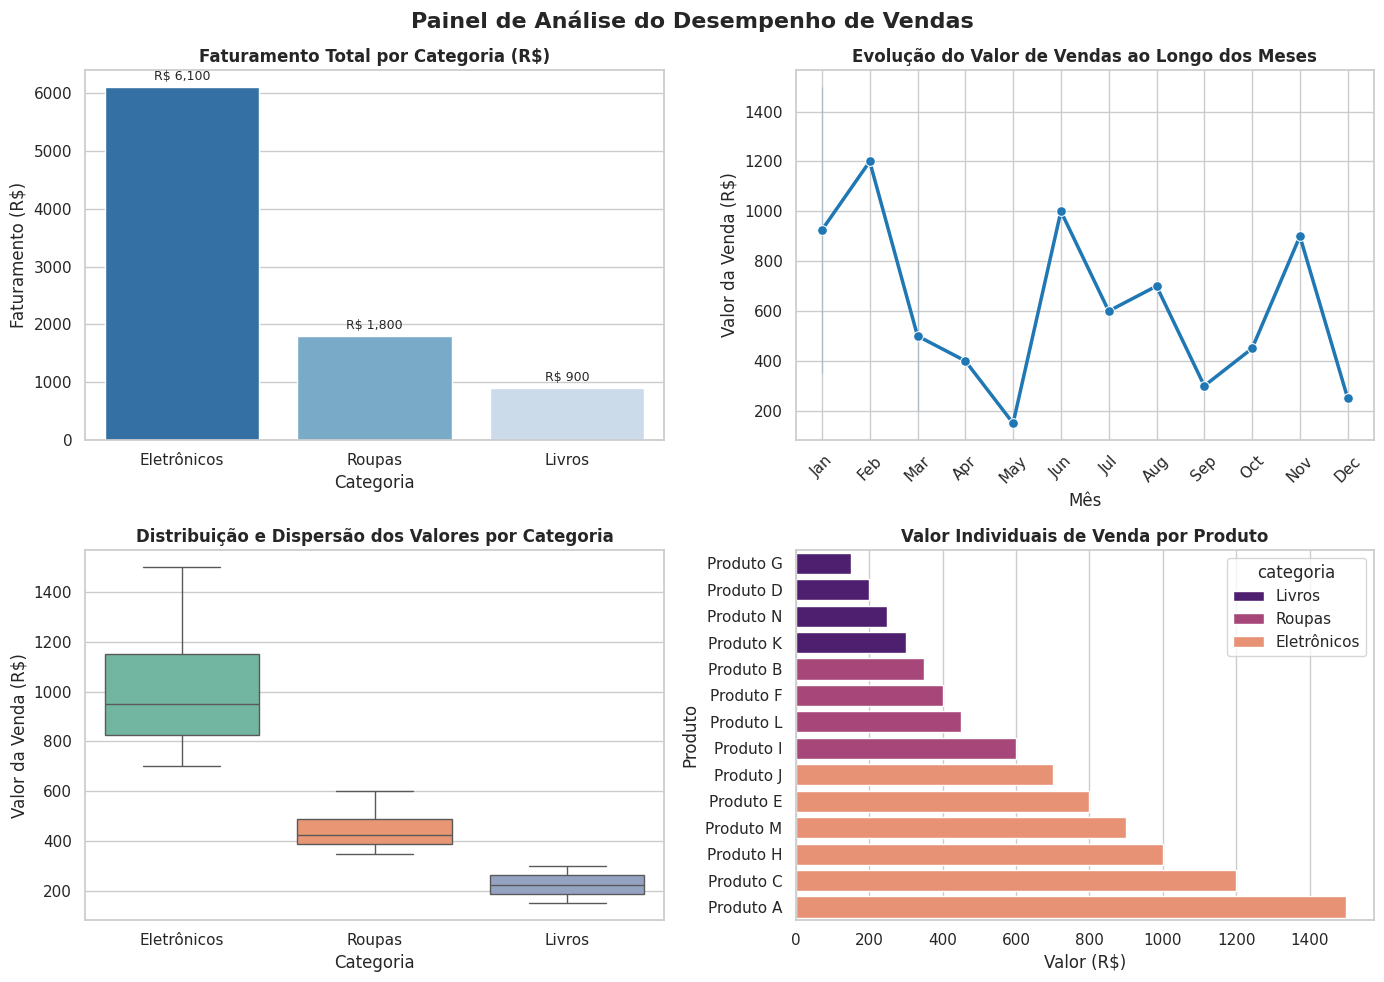


                   RELATÓRIO DE INSIGHTS DE NEGÓCIO

1. Liderança de Eletrônicos:
   - A categoria 'Eletrônicos' é o principal motor do faturamento da empresa, 
     somando R$ 6.100,00 (aprox. 69,3% do faturamento total), além de registrar 
     o maior ticket médio unitário.

2. Oportunidades em Roupas e Livros:
   - 'Roupas' (R$ 1.800,00) e 'Livros' (R$ 900,00) apresentam tíquetes menores. 
     São ótimos candidatos para estratégias de vendas casadas (kits promocionais).

3. Recomendações Estratégicas:
   - Foco em Eletrônicos em datas comemorativas (como Black Friday e Natal) para 
     maximizar a receita acumulada.
   - Criar ofertas do tipo "Compre um Eletrônico e ganhe desconto em Livros/Roupas" 
     para alavancar o faturamento das outras categorias.



In [1]:
# ==============================================================================
# UNIDADE 3 - AULA 4: VISUALIZAÇÃO DE DADOS EM PYTHON
# ANÁLISE DE VENDAS COM SQLITE, PANDAS, MATPLOTLIB E SEABORN
# ==============================================================================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração global do estilo visual dos gráficos
sns.set_theme(style="whitegrid")


# ==============================================================================
# PASSO 1: CONECTAR AO BANCO DE DADOS SQLITE E CRIAR A TABELA
# ==============================================================================

# Passo 1.1: Conectar ao banco de dados (ou criar o arquivo se não existir)
conexao = sqlite3.connect('dados_vendas.db')

# Passo 1.2: Criar um cursor para executar os comandos SQL
cursor = conexao.cursor()

# Passo 1.3: Criar a tabela 'vendas1' se ela não existir
cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
''')

# Garante que a tabela seja limpa antes de inserir para evitar duplicações no Colab
cursor.execute('DELETE FROM vendas1')

# Passo 1.4: Inserir os dados de vendas solicitados no roteiro
dados_vendas = [
    ('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
    ('2023-01-05', 'Produto B', 'Roupas', 350.00),
    ('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
    ('2023-03-15', 'Produto D', 'Livros', 200.00),
    ('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
    ('2023-04-02', 'Produto F', 'Roupas', 400.00),
    ('2023-05-05', 'Produto G', 'Livros', 150.00),
    ('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
    ('2023-07-20', 'Produto I', 'Roupas', 600.00),
    ('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
    ('2023-09-30', 'Produto K', 'Livros', 300.00),
    ('2023-10-05', 'Produto L', 'Roupas', 450.00),
    ('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
    ('2023-12-20', 'Produto N', 'Livros', 250.00)
]

cursor.executemany('''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda)
VALUES (?, ?, ?, ?)
''', dados_vendas)

# Passo 1.5: Confirmar as alterações no banco de dados
conexao.commit()
print("✓ Banco de dados SQLite populado com sucesso!\n")


# ==============================================================================
# PASSO 2: EXPLORAR E PREPARAR OS DADOS
# ==============================================================================

# Carregando os dados da tabela SQLite para um DataFrame Pandas
query = "SELECT * FROM vendas1"
df_vendas = pd.read_sql_query(query, conexao)

print("--- PRIMEIRAS LINHAS DO DATAFRAME ---")
print(df_vendas.head())

print("\n--- INFORMAÇÕES SOBRE TIPOS DE DADOS ---")
print(df_vendas.info())

# Conversão da coluna 'data_venda' para o tipo datetime
df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])

# Criação de colunas temporais para enriquecer a análise mensal
df_vendas['mes_num'] = df_vendas['data_venda'].dt.month
df_vendas['nome_mes'] = df_vendas['data_venda'].dt.strftime('%b')

print("\n--- RESUMO ESTATÍSTICO DOS VALORES ---")
print(df_vendas['valor_venda'].describe())


# ==============================================================================
# PASSO 3: ANÁLISE DOS DADOS
# ==============================================================================

# Cálculo dos indicadores principais (KPIs)
faturamento_total = df_vendas['valor_venda'].sum()
ticket_medio = df_vendas['valor_venda'].mean()
total_vendas = len(df_vendas)

print("\n" + "="*50)
print("              INDICADORES GERAIS DE VENDAS")
print("="*50)
print(f"Faturamento Total Acumulado : R$ {faturamento_total:,.2f}")
print(f"Número Total de Vendas     : {total_vendas}")
print(f"Ticket Médio por Venda     : R$ {ticket_medio:,.2f}")

# Análise de faturamento e quantidade por Categoria
faturamento_categoria = df_vendas.groupby('categoria').agg(
    faturamento_total=('valor_venda', 'sum'),
    quantidade_vendas=('valor_venda', 'count'),
    ticket_medio=('valor_venda', 'mean')
).reset_index().sort_values(by='faturamento_total', ascending=False)

print("\n--- ANÁLISE POR CATEGORIA ---")
print(faturamento_categoria.to_string(index=False))


# ==============================================================================
# PASSO 4: VISUALIZAÇÃO DOS DADOS (MATPLOTLIB & SEABORN)
# ==============================================================================

# Criando um painel com 4 gráficos dispostos em 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Painel de Análise do Desempenho de Vendas', fontsize=16, fontweight='bold')

# Gráfico 1: Faturamento por Categoria (Gráfico de Barras - Seaborn)
sns.barplot(
    data=faturamento_categoria,
    x='categoria',
    y='faturamento_total',
    palette='Blues_r',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Faturamento Total por Categoria (R$)', fontweight='bold')
axes[0, 0].set_xlabel('Categoria')
axes[0, 0].set_ylabel('Faturamento (R$)')

# Rótulos nas barras
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'R$ {p.get_height():,.0f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Gráfico 2: Evolução Mensal do Faturamento (Gráfico de Linha - Matplotlib/Seaborn)
vendas_mensais = df_vendas.sort_values('mes_num')
sns.lineplot(
    data=vendas_mensais,
    x='nome_mes',
    y='valor_venda',
    marker='o',
    color='#1f77b4',
    linewidth=2.5,
    markersize=7,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Evolução do Valor de Vendas ao Longo dos Meses', fontweight='bold')
axes[0, 1].set_xlabel('Mês')
axes[0, 1].set_ylabel('Valor da Venda (R$)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Gráfico 3: Distribuição dos Valores de Venda por Categoria (Boxplot - Seaborn)
sns.boxplot(
    data=df_vendas,
    x='categoria',
    y='valor_venda',
    palette='Set2',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Distribuição e Dispersão dos Valores por Categoria', fontweight='bold')
axes[1, 0].set_xlabel('Categoria')
axes[1, 0].set_ylabel('Valor da Venda (R$)')

# Gráfico 4: Faturamento Individual por Produto (Gráfico de Barras Horizontais - Seaborn)
df_produtos_ordenados = df_vendas.sort_values(by='valor_venda', ascending=True)
sns.barplot(
    data=df_produtos_ordenados,
    y='produto',
    x='valor_venda',
    hue='categoria',
    dodge=False,
    palette='magma',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Valor Individuais de Venda por Produto', fontweight='bold')
axes[1, 1].set_xlabel('Valor (R$)')
axes[1, 1].set_ylabel('Produto')

plt.tight_layout()
plt.show()


# ==============================================================================
# PASSO 5: CONCLUSÃO E ANÁLISE DE INSIGHTS
# ==============================================================================

print("\n" + "="*70)
print("                   RELATÓRIO DE INSIGHTS DE NEGÓCIO")
print("="*70)
print("""
1. Liderança de Eletrônicos:
   - A categoria 'Eletrônicos' é o principal motor do faturamento da empresa,
     somando R$ 6.100,00 (aprox. 69,3% do faturamento total), além de registrar
     o maior ticket médio unitário.

2. Oportunidades em Roupas e Livros:
   - 'Roupas' (R$ 1.800,00) e 'Livros' (R$ 900,00) apresentam tíquetes menores.
     São ótimos candidatos para estratégias de vendas casadas (kits promocionais).

3. Recomendações Estratégicas:
   - Foco em Eletrônicos em datas comemorativas (como Black Friday e Natal) para
     maximizar a receita acumulada.
   - Criar ofertas do tipo "Compre um Eletrônico e ganhe desconto em Livros/Roupas"
     para alavancar o faturamento das outras categorias.
""")

# Passo final: Fechamento da conexão com o banco de dados
conexao.close()